In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier

In [2]:
# ── Plotting theme ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
CLASSES = ["negative", "neutral", "positive"]
CLASS_COLORS = {"negative": "#E74C3C", "neutral": "#F1C40F", "positive": "#2ECC71"}

In [3]:
# ── 1. Load cleaned data ────────────────────────────────────────────────────
csv_path = "cleaned_reviews.csv"

df = pd.read_csv(csv_path)
df["clean"] = df["clean"].fillna("")
print(f"Loaded: {df.shape}  |  Label counts:\n{df['sentiment'].value_counts()}")
 
X = df["clean"]
y = df["sentiment"]

Loaded: (1440, 16)  |  Label counts:
sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


In [4]:
# ── 2. Train / test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}  Test: {len(X_test)}")


Train: 1152  Test: 288


In [5]:
# ── 3. TF-IDF vectorizer (shared) ───────────────────────────────────────────
TFIDF = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words="english",
)

In [6]:
from sklearn.svm import SVC

In [7]:
# ── 4. Define models ─────────────────────────────────────────────────────────
MODELS = {
    "Logistic Regression":       LogisticRegression(max_iter=500, C=1.0, random_state=42),
    "Multinomial Naive Bayes":   MultinomialNB(alpha=0.5),
    "Complement Naive Bayes":    ComplementNB(alpha=0.5),
    "Linear SVM":                LinearSVC(C=1.0, max_iter=2000, random_state=42),
    "Random Forest":             RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":         GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    "K-Nearest Neighbours":      KNeighborsClassifier(n_neighbors=7, metric="cosine"),
    "Voting Ensemble":           VotingClassifier(
        estimators=[
            ("lr",  LogisticRegression(max_iter=500, C=1.0, random_state=42)),
            ("svm", LinearSVC(C=1.0, max_iter=2000, random_state=42)),
            ("cnb", ComplementNB(alpha=0.5)),
        ],
        voting="hard",
    ),
}

In [8]:
# ── 5. Train, evaluate & collect metrics ─────────────────────────────────────
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
for name, clf in MODELS.items():
    pipe = Pipeline([("tfidf", TFIDF), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
 
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="weighted")
    cv   = cross_val_score(pipe, X_train, y_train, cv=skf,
                           scoring="f1_weighted", n_jobs=-1).mean()
 
    results[name] = {
        "pipeline":  pipe,
        "y_pred":    y_pred,
        "accuracy":  acc,
        "f1_weighted": f1,
        "cv_f1":     cv,
    }
    print(f"{name:30s}  acc={acc:.3f}  f1={f1:.3f}  cv_f1={cv:.3f}")

Logistic Regression             acc=0.785  f1=0.736  cv_f1=0.729
Multinomial Naive Bayes         acc=0.774  f1=0.715  cv_f1=0.705
Complement Naive Bayes          acc=0.785  f1=0.733  cv_f1=0.741
Linear SVM                      acc=0.785  f1=0.748  cv_f1=0.754
Random Forest                   acc=0.764  f1=0.711  cv_f1=0.708
Gradient Boosting               acc=0.729  f1=0.699  cv_f1=0.730
K-Nearest Neighbours            acc=0.750  f1=0.707  cv_f1=0.709
Voting Ensemble                 acc=0.799  f1=0.752  cv_f1=0.743


In [9]:
# ── 6. Model comparison bar chart ────────────────────────────────────────────
comp = pd.DataFrame({
    "Model":    list(results.keys()),
    "Accuracy": [results[m]["accuracy"]   for m in results],
    "F1 (test)": [results[m]["f1_weighted"] for m in results],
    "CV F1":    [results[m]["cv_f1"]      for m in results],
}).set_index("Model")

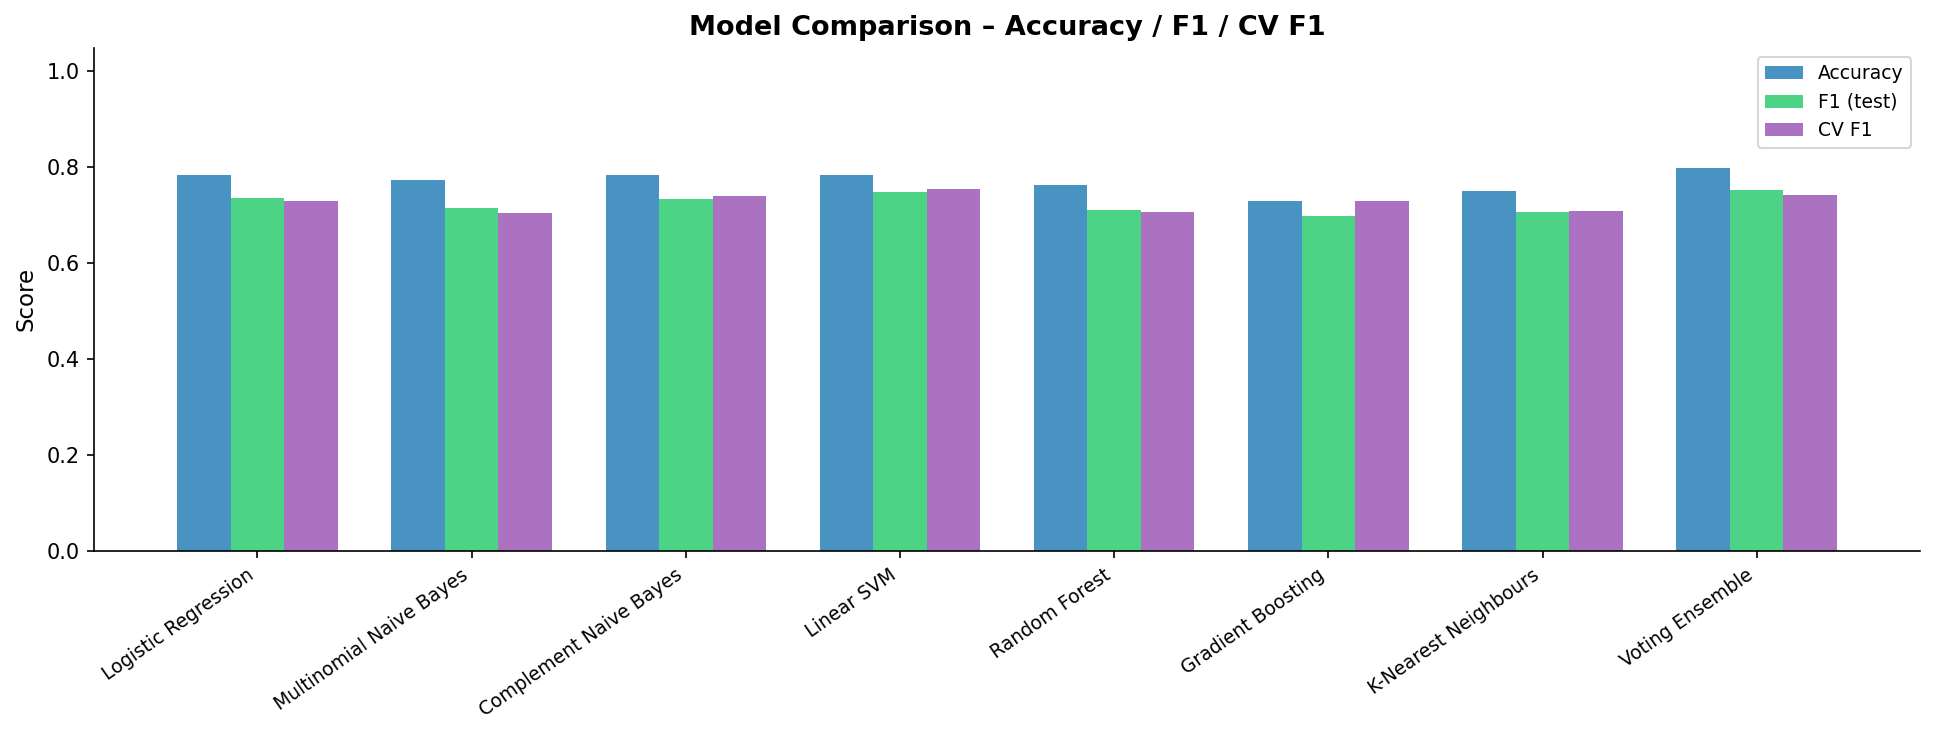

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(comp))
width = 0.25
ax.bar(x - width, comp["Accuracy"],  width, label="Accuracy",  color="#2980B9", alpha=0.85)
ax.bar(x,         comp["F1 (test)"], width, label="F1 (test)", color="#2ECC71", alpha=0.85)
ax.bar(x + width, comp["CV F1"],     width, label="CV F1",     color="#9B59B6", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison – Accuracy / F1 / CV F1", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# ── 7. Classification reports ────────────────────────────────────────────────
with open("classification_reports.txt", "w") as f:
    for name, res in results.items():
        f.write(f"\n{'='*60}\n{name}\n{'='*60}\n")
        f.write(classification_report(y_test, res["y_pred"], target_names=CLASSES))
print("Saved → classification_reports.txt")

Saved → classification_reports.txt


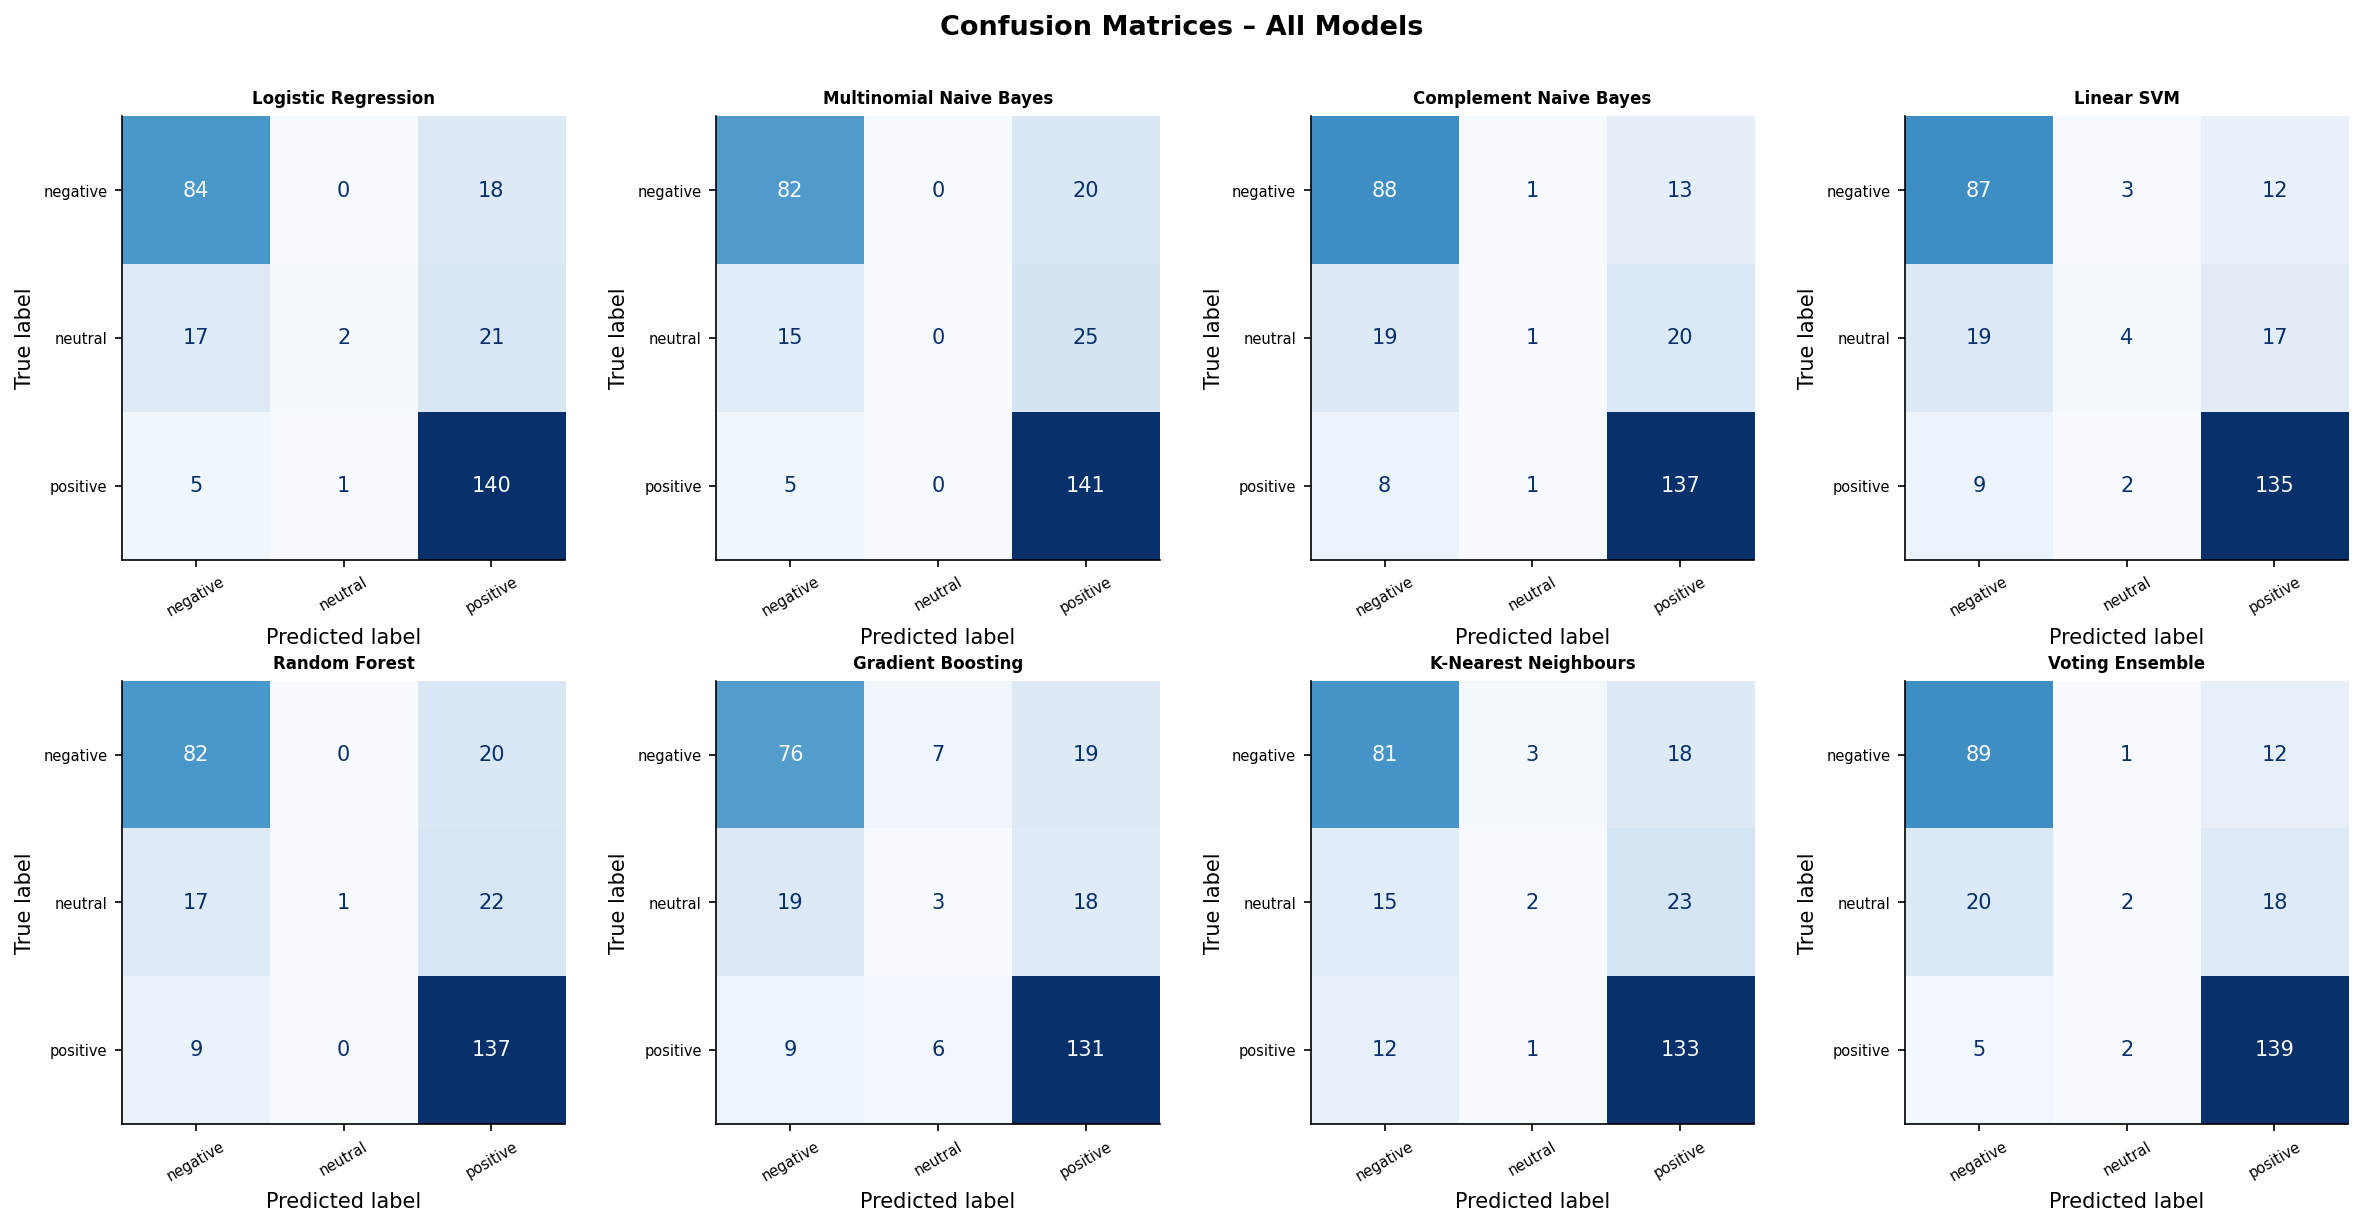

In [12]:
# ── 8. Confusion matrices (all models) ───────────────────────────────────────
n_models = len(MODELS)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes_flat = axes.flatten()
 
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_pred"], labels=CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=axes_flat[i], colorbar=False, cmap="Blues")
    axes_flat[i].set_title(name, fontsize=8, fontweight="bold")
    axes_flat[i].set_xticklabels(CLASSES, rotation=30, fontsize=7)
    axes_flat[i].set_yticklabels(CLASSES, fontsize=7)
 
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")
 
plt.suptitle("Confusion Matrices – All Models", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Skipping Voting Ensemble — no probability output


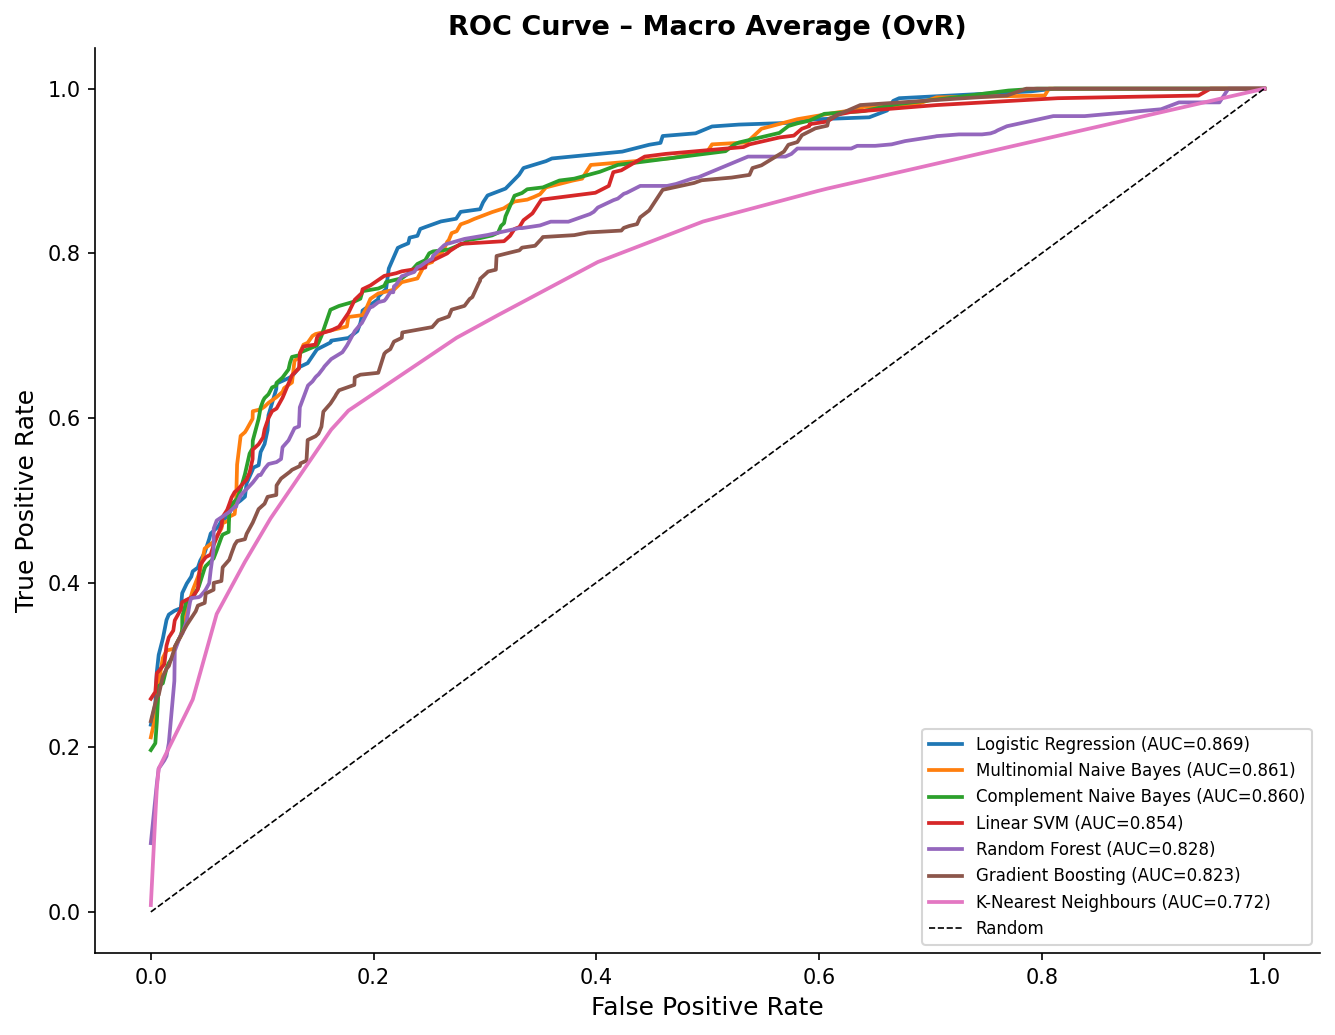

In [13]:
# ── 9. ROC-AUC curves (OvR, macro) ──────────────────────────────────────────
# Only models with predict_proba (LinearSVC uses decision_function)
PROBA_MODELS = {k: v for k, v in results.items()
                if hasattr(v["pipeline"].named_steps["clf"], "predict_proba")
                or hasattr(v["pipeline"].named_steps["clf"], "decision_function")}
 
label_encoder = LabelEncoder().fit(CLASSES)
y_test_enc = label_encoder.transform(y_test)
y_bin = label_binarize(y_test_enc, classes=[0, 1, 2])   # shape (n, 3)
 
fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.cm.get_cmap("tab10")
 
for idx, (name, res) in enumerate(results.items()):
    pipe = res["pipeline"]
    clf  = pipe.named_steps["clf"]
    X_test_tfidf = pipe.named_steps["tfidf"].transform(X_test)

    # Skip models that can't produce probability/score estimates
    if not hasattr(clf, "predict_proba") and not hasattr(clf, "decision_function"):
        print(f"Skipping {name} — no probability output")
        continue

    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test_tfidf)
    else:
        scores = clf.decision_function(X_test_tfidf)
        scores = scores - scores.min(axis=0)
        scores = scores / (scores.max(axis=0) + 1e-9)
 
    # Macro-average ROC
    fpr_all, tpr_all, roc_all = {}, {}, {}
    for ci in range(3):
        fpr_all[ci], tpr_all[ci], _ = roc_curve(y_bin[:, ci], scores[:, ci])
        roc_all[ci] = auc(fpr_all[ci], tpr_all[ci])
 
    # Macro
    all_fpr   = np.unique(np.concatenate([fpr_all[ci] for ci in range(3)]))
    mean_tpr  = np.zeros_like(all_fpr)
    for ci in range(3):
        mean_tpr += np.interp(all_fpr, fpr_all[ci], tpr_all[ci])
    mean_tpr /= 3
    macro_auc = auc(all_fpr, mean_tpr)
 
    ax.plot(all_fpr, mean_tpr,
            label=f"{name} (AUC={macro_auc:.3f})",
            color=cmap(idx), linewidth=1.8)
 
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve – Macro Average (OvR)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [14]:
# ── 10. Per-class ROC for best model ─────────────────────────────────────────
best_name = max(results, key=lambda m: results[m]["f1_weighted"])
print(f"\nBest model: {best_name}")
best_pipe = results[best_name]["pipeline"]
best_clf  = best_pipe.named_steps["clf"]
X_test_tf = best_pipe.named_steps["tfidf"].transform(X_test)

# Safely get scores — try predict_proba first, then decision_function
if hasattr(best_clf, "predict_proba"):
    scores = best_clf.predict_proba(X_test_tf)
elif hasattr(best_clf, "decision_function"):
    scores = best_clf.decision_function(X_test_tf)
    # Normalize to [0,1] range so it works like probabilities
    scores = scores - scores.min(axis=0)
    scores = scores / (scores.max(axis=0) + 1e-9)
else:
    print(f"⚠️ {best_name} supports neither predict_proba nor decision_function — skipping per-class ROC")
    scores = None

if scores is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    for ci, (cname, color) in enumerate(CLASS_COLORS.items()):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], scores[:, ci])
        ax.plot(fpr, tpr, label=f"{cname} (AUC={auc(fpr,tpr):.3f})", color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"Per-Class ROC – {best_name}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


Best model: Voting Ensemble
⚠️ Voting Ensemble supports neither predict_proba nor decision_function — skipping per-class ROC


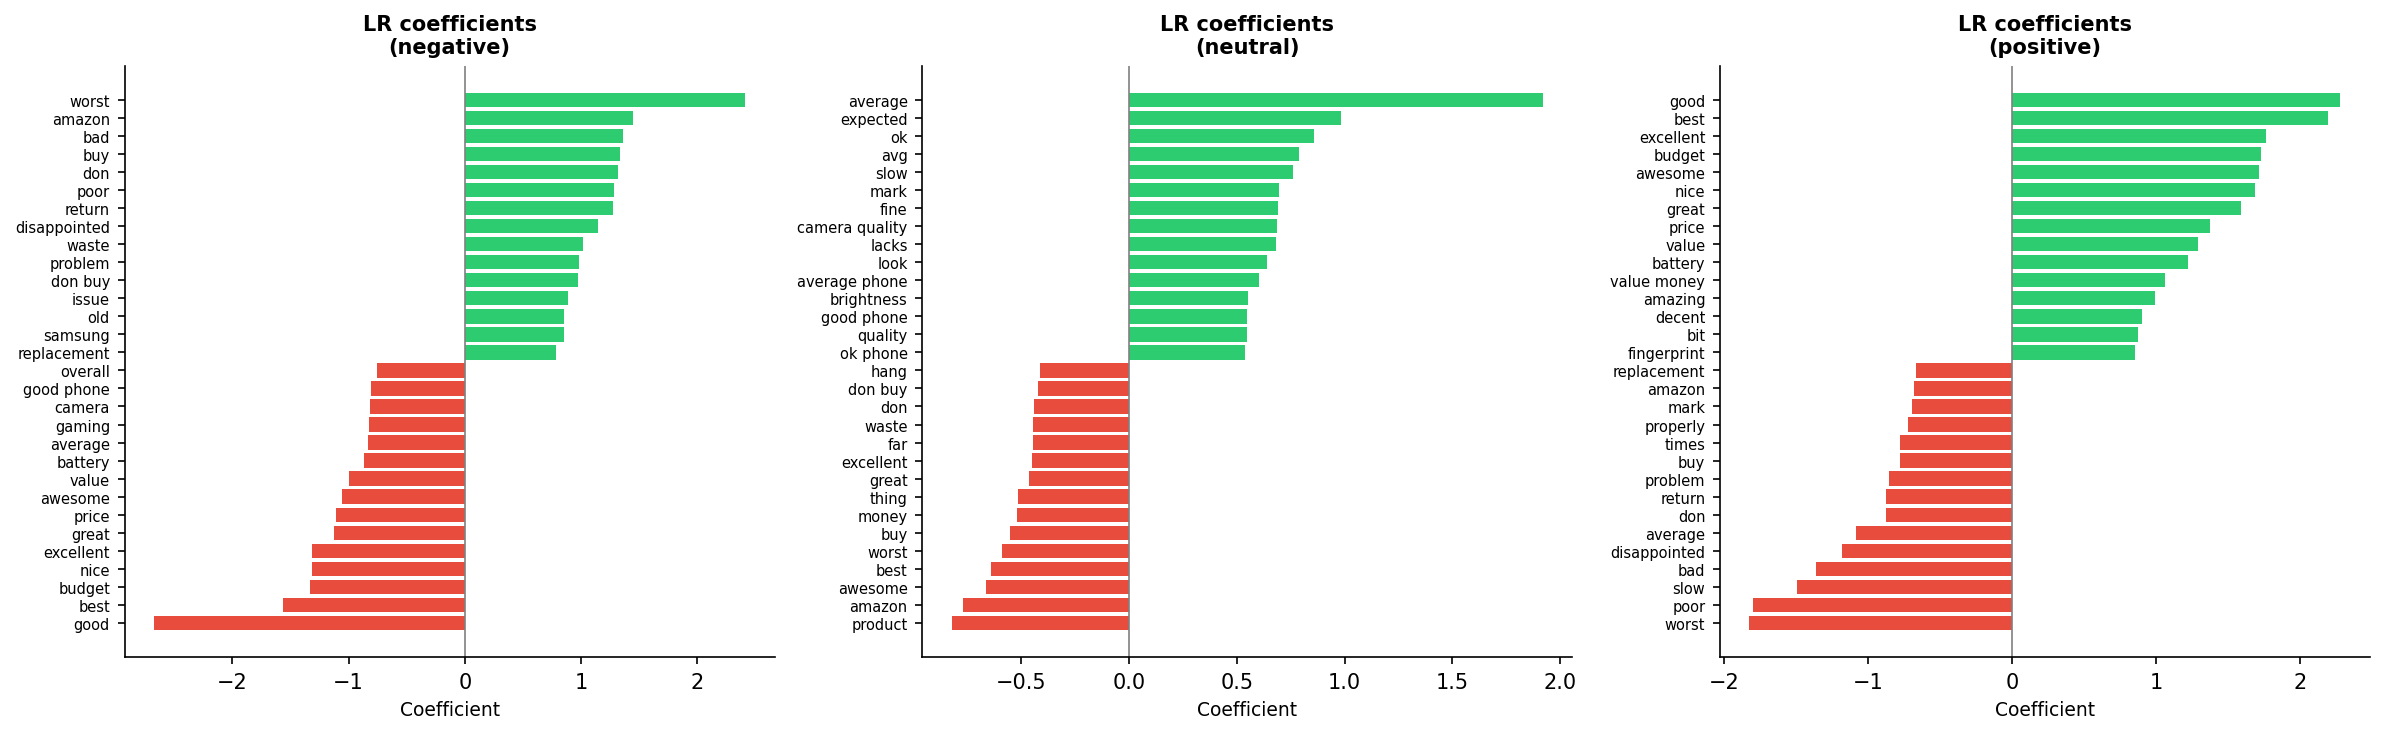

In [15]:
# ── 11. Feature importance (Logistic Regression coefficients) ────────────────
lr_pipe = results["Logistic Regression"]["pipeline"]
lr_clf  = lr_pipe.named_steps["clf"]
feature_names = lr_pipe.named_steps["tfidf"].get_feature_names_out()
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ci, (cls, ax) in enumerate(zip(CLASSES, axes)):
    coefs = lr_clf.coef_[ci]
    top_pos = np.argsort(coefs)[-15:]
    top_neg = np.argsort(coefs)[:15]
    top_idx = np.concatenate([top_neg, top_pos])
    colors  = ["#E74C3C"] * 15 + ["#2ECC71"] * 15
    ax.barh(feature_names[top_idx], coefs[top_idx], color=colors, edgecolor="none")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_title(f"LR coefficients\n({cls})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Coefficient", fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

In [16]:
# ── 12. Save best model ───────────────────────────────────────────────────────
joblib.dump(results[best_name]["pipeline"], "best_model.pkl")
print(f"\nBest model pipeline saved → best_model.pkl")
print(f"Best model  : {best_name}")
print(f"Test Accuracy: {results[best_name]['accuracy']:.4f}")
print(f"Test F1      : {results[best_name]['f1_weighted']:.4f}")


Best model pipeline saved → best_model.pkl
Best model  : Voting Ensemble
Test Accuracy: 0.7986
Test F1      : 0.7516
